<img src="https://www.collinsdictionary.com/images/full/xray_560923156_1000.jpg" width="620" height="360" align="center"/>

<br>
<h1 style = "font-size:30px; font-weight : bold; color : blue; text-align: center; border-radius: 10px 15px;">Chest X-Ray (Pneumonia): Image Classification w/Convolutional Neural Networks and Transfer Learning</h1>
تصوير الصدر بالأشعة السينية والالتهاب الرئوي
---

# Overview

The goal of this notebook is to use Convolutional Neural Networks on Chest X-Ray images to determine which samples are from patients with Pneumonia. In this dataset (version 3), there is one folder representing the train set and another one for the test set. The train folder is later split in the notebook into train/validation sets.

I use three different approaches for image classification: 1) A simple CNN, 2) Transfer Learning, using a pretrained model with frozen layers as the base for feature extraction and 3) Fine Tuning, unfreezing the last layers of the pretrained model.

Note: I’m using the third version of the Chest X-Ray dataset [(link)](https://www.kaggle.com/tolgadincer/labeled-chest-xray-images)

# <a id='0'>Content</a>
​
- <a href='#1'>Dataset Information</a>  
- <a href='#2'>Importing Packages and Dataset</a>  
- <a href='#3'>Exploring the Data</a>  
- <a href='#4'>Preparing the Data</a>
- <a href='#5'>Custom Model</a>
- <a href='#6'>Transfer Learning</a>
- <a href='#7'>Fine Tuning</a>
- <a href='#8'>Performance Metrics</a>
- <a href='#9'>References</a>

# <a id="1">Dataset Information</a>

This dataset contains 5,856 validated Chest X-Ray images. The images are split into a training set and a testing set of independent patients. Images are labeled as (disease:NORMAL/BACTERIA/VIRUS)-(randomized patient ID)-(image number of a patient).

Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.

For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.

## <center> If you find this notebook useful, support with an upvote! <center>

# <a id="2">Importing Packages and Dataset</a>

In [ ]:
# prompt: need to download the datset in kaggle urel https://www.kaggle.com/code/jonaspalucibarbosa/chest-x-ray-pneumonia-cnn-transfer-learning/input
!pip install kaggle

In [ ]:
import pandas as pd
import matplotlib as mat
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

pd.options.display.max_colwidth = 100

import random
import os

from numpy.random import seed
seed(42)

random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import glob
import cv2

from tensorflow.random import set_seed
set_seed(42)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
files.upload()

!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d tolgadincer/labeled-chest-xray-images
!unzip labeled-chest-xray-images.zip


Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
License(s): other
 90% 1.05G/1.17G [00:13<00:01, 119MB/s]

In [ ]:
# prompt: read test and train folders in two varables using image data generator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2,
                                   subset="training") # set validation split

test_datagen = ImageDataGenerator(rescale=1./255,
                                   ) # set validation split

train_generator = train_datagen.flow_from_directory(
    'chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    ) # set as training data

test_generator = test_datagen.flow_from_directory(
    'chest_xray/test', # same directory as training data
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
   ) # set as validation data


valid_generator = train_datagen.flow_from_directory(
    'chest_xray/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset="validation")


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
IMG_SIZE = 224
BATCH = 32
SEED = 42

# <a id="3">Exploring the Data</a>

Let's check the target distribution on each set

The distributions from these datasets are a little different from each other. Both are slightly imbalanced, having more samples from the positive class (Pneumonia), with the training set being a little more imbalanced.

Before we move on to the next section, we will take a look at a few examples from each dataset.

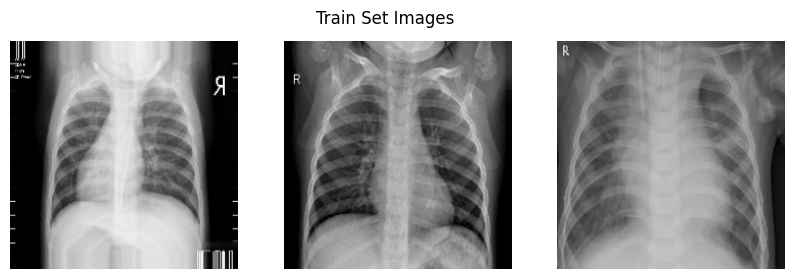

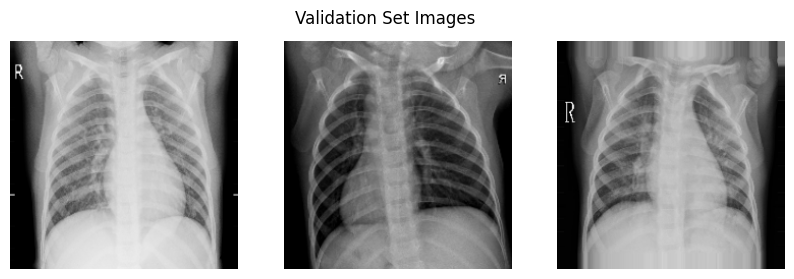

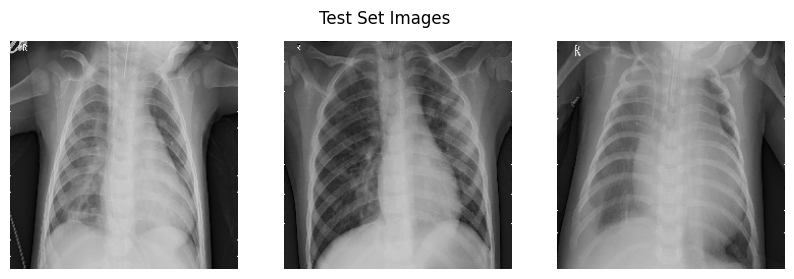

In [ ]:
# prompt: print 3 images from every folder in train_generator, validation, test , every three images in one row

import matplotlib.pyplot as plt

def plot_images(generator, title):
  """Plots 3 images from a generator in a row."""
  x, y = next(generator)
  fig, axes = plt.subplots(1, 3, figsize=(10, 3))
  fig.suptitle(title, fontsize=12)
  for i in range(3):
    axes[i].imshow(x[i])
    axes[i].axis('off')
  plt.show()

plot_images(train_generator, "Train Set Images")
plot_images(valid_generator, "Validation Set Images")
plot_images(test_generator, "Test Set Images")


# <a id="4">Preparing the Data</a>

Now, we are ready for the next stage: creating and training the image classification models.

# <a id="5">Custom CNN</a>

In [ ]:
# need to add checkpoint for saving the best model, reduce on plateur, early stoping

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="CNN.weights.h5",
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=3, min_lr=0.001)

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=valid_generator,
    callbacks=[model_checkpoint_callback, early_stopping, reduce_lr])

Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 634ms/step - accuracy: 0.8132 - loss: 0.4033 - val_accuracy: 0.5625 - val_loss: 1.6933 - learning_rate: 0.0010
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 611ms/step - accuracy: 0.9154 - loss: 0.2088 - val_accuracy: 0.6250 - val_loss: 1.7640 - learning_rate: 0.0010
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 608ms/step - accuracy: 0.9276 - loss: 0.1792 - val_accuracy: 0.5625 - val_loss: 1.1144 - learning_rate: 0.0010
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 614ms/step - accuracy: 0.9456 - loss: 0.1529 - val_accuracy: 0.6875 - val_loss: 0.7881 - learning_rate: 0.0010
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 624ms/step - accuracy: 0.9390 - loss: 0.1509 - val_accuracy: 0.5625 - val_loss: 1.1715 - learning_rate: 0.0010
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 604ms/step - accuracy: 0.9295 - loss: 0.1611 - val_accuracy: 0.5625 - val_loss: 0.8055 - learning_rate: 0.0010
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 613ms/step -

In [ ]:
def get_model():

    #Input shape = [width, height, color channels]
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Block One
    x = layers.Conv2D(filters=16, kernel_size=3, padding='valid')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.2)(x)

    # Block Two
    x = layers.Conv2D(filters=32, kernel_size=3, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.2)(x)

    # Block Three
    x = layers.Conv2D(filters=64, kernel_size=3, padding='valid')(x)
    x = layers.Conv2D(filters=64, kernel_size=3, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.4)(x)

    # Head
    #x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    #Final Layer (Output)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=[inputs], outputs=output)

    return model

In [ ]:
keras.backend.clear_session()

model = get_model()
model.compile(loss='binary_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=3e-5), metrics='binary_accuracy')

model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 222, 222, 16)      448       
_________________________________________________________________
batch_normalization (BatchNo (None, 222, 222, 16)      64        
_________________________________________________________________
activation (Activation)      (None, 222, 222, 16)      0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 111, 111, 16)      0         
_________________________________________________________________
dropout (Dropout)            (None, 111, 111, 16)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 109, 109, 32)      4640  

In [ ]:
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=valid_generator,
    callbacks=[model_checkpoint_callback, early_stopping, reduce_lr])

Epoch 1/50
130/130 [==============================] - 101s 767ms/step - loss: 0.6391 - binary_accuracy: 0.7145 - val_loss: 0.7722 - val_binary_accuracy: 0.7421
Epoch 2/50
130/130 [==============================] - 100s 766ms/step - loss: 0.3928 - binary_accuracy: 0.8159 - val_loss: 1.2521 - val_binary_accuracy: 0.7421
Epoch 3/50
130/130 [==============================] - 100s 768ms/step - loss: 0.3035 - binary_accuracy: 0.8698 - val_loss: 1.4061 - val_binary_accuracy: 0.7421

Epoch 00003: ReduceLROnPlateau reducing learning rate to 5.9999998484272515e-06.
Epoch 4/50
130/130 [==============================] - 100s 765ms/step - loss: 0.2445 - binary_accuracy: 0.8957 - val_loss: 1.1610 - val_binary_accuracy: 0.7421
Epoch 5/50
130/130 [==============================] - 100s 764ms/step - loss: 0.2176 - binary_accuracy: 0.9116 - val_loss: 0.5502 - val_binary_accuracy: 0.7784
Epoch 6/50
130/130 [==============================] - 99s 759ms/step - loss: 0.2325 - binary_accuracy: 0.9110 - val_lo

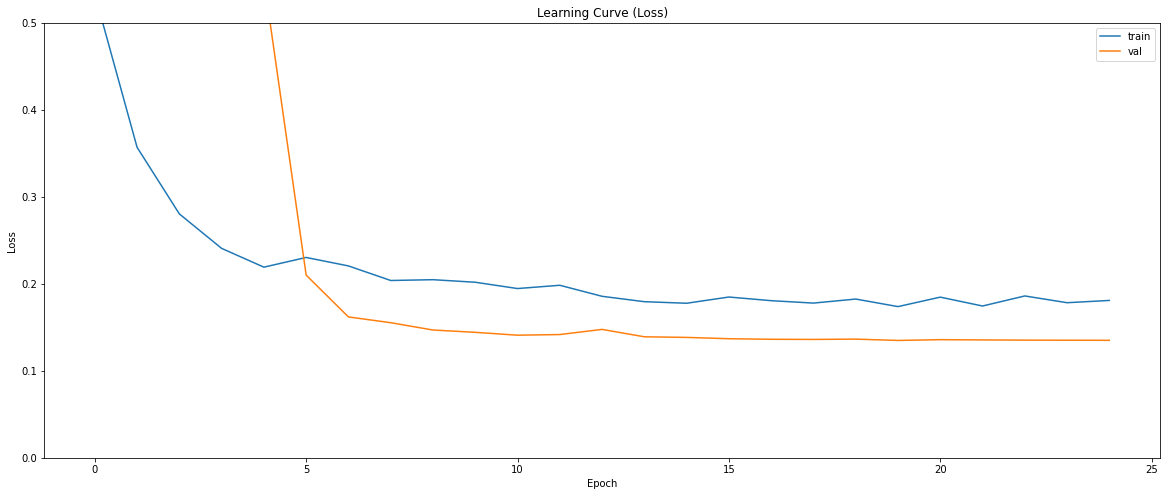

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 0.5)
ax.legend(['train', 'val'], loc='best')
plt.show()

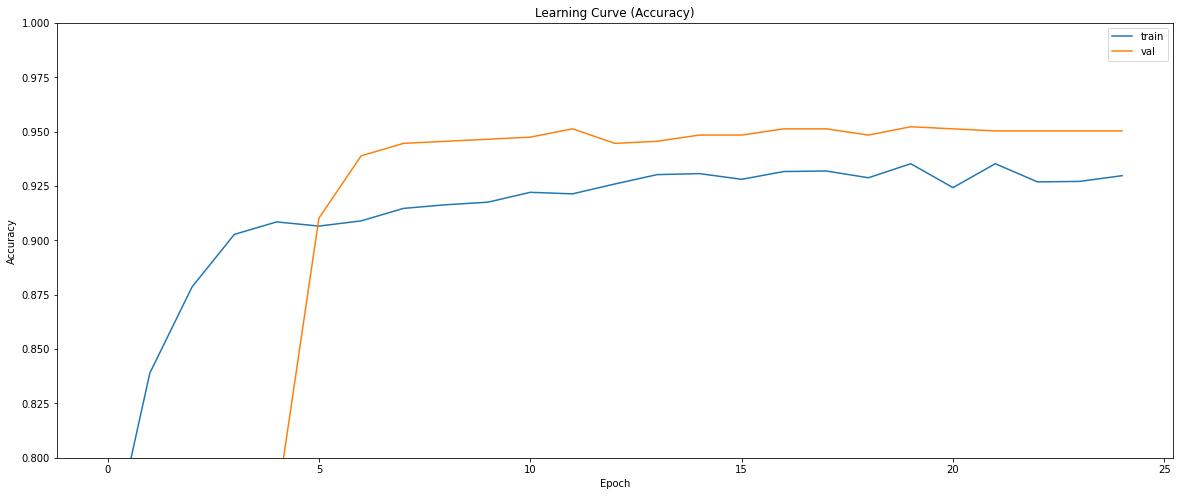

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['binary_accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_binary_accuracy'])
ax.set_title('Learning Curve (Accuracy)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim(0.80, 1.0)
ax.legend(['train', 'val'], loc='best')
plt.show()

In [ ]:
score = model.evaluate(valid_generator, verbose = 0)
print('Val loss:', score[0])
print('Val accuracy:', score[1])

Val loss: 0.1349286437034607
Val accuracy: 0.9522445201873779


In [ ]:
score = model.evaluate(test_datagen, steps = len(test_datagen), verbose = 0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.4296790361404419
Test accuracy: 0.8493589758872986


# <a id="6">Transfer Learning</a>

The second approach, called transfer learning, consists of using a pretrained model as a feature extractor. In this notebook, the selected model was the ResNet152V2 available on the Keras Package [(link)](https://keras.io/api/applications/resnet/#resnet152v2-function).

This model was already trained in another dataset (ImageNet). What we do here is to set include_top to false, removing the ‘head’, responsible for assigning the classes in this other dataset, and keep all the previous layers. Then, we include our last few layers, including the one responsible for generating the output.



In [ ]:
base_model = tf.keras.applications.ResNet152V2(
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False)

base_model.trainable = False

def get_pretrained():

    #Input shape = [width, height, color channels]
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.1)(x)

    #Final Layer (Output)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=[inputs], outputs=output)

    return model

234553344/234545216 [==============================] - 1s 0us/step


In [ ]:
keras.backend.clear_session()

model_pretrained = get_pretrained()
model_pretrained.compile(loss='binary_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=5e-5), metrics='binary_accuracy')

model_pretrained.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
resnet152v2 (Functional)     (None, 7, 7, 2048)        58331648  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               262272    
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 129       
Total params: 58,594,049
Trainable params: 262,401
Non-trainable params: 58,331,648
___________________________________________

In [ ]:
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=valid_generator,
    callbacks=[model_checkpoint_callback, early_stopping, reduce_lr])

Epoch 1/50
130/130 [==============================] - 116s 823ms/step - loss: 0.6397 - binary_accuracy: 0.6697 - val_loss: 0.2379 - val_binary_accuracy: 0.9179
Epoch 2/50
130/130 [==============================] - 103s 791ms/step - loss: 0.2347 - binary_accuracy: 0.9156 - val_loss: 0.1784 - val_binary_accuracy: 0.9379
Epoch 3/50
130/130 [==============================] - 103s 791ms/step - loss: 0.1833 - binary_accuracy: 0.9363 - val_loss: 0.1586 - val_binary_accuracy: 0.9475
Epoch 4/50
130/130 [==============================] - 105s 803ms/step - loss: 0.1761 - binary_accuracy: 0.9292 - val_loss: 0.1418 - val_binary_accuracy: 0.9522
Epoch 5/50
130/130 [==============================] - 105s 803ms/step - loss: 0.1471 - binary_accuracy: 0.9466 - val_loss: 0.1347 - val_binary_accuracy: 0.9561
Epoch 6/50
130/130 [==============================] - 103s 790ms/step - loss: 0.1403 - binary_accuracy: 0.9473 - val_loss: 0.1278 - val_binary_accuracy: 0.9561
Epoch 7/50
130/130 [====================

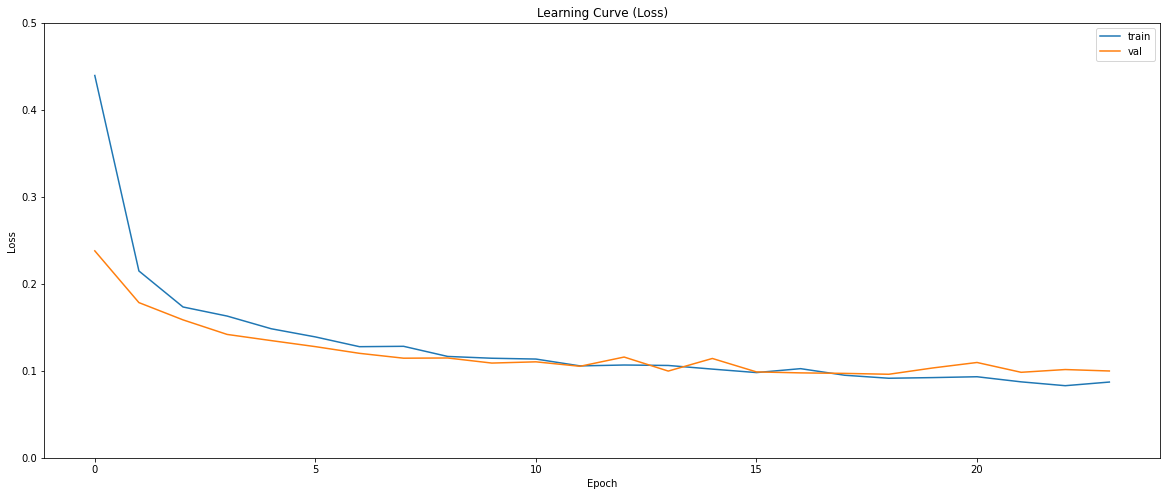

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 0.5)
ax.legend(['train', 'val'], loc='best')
plt.show()

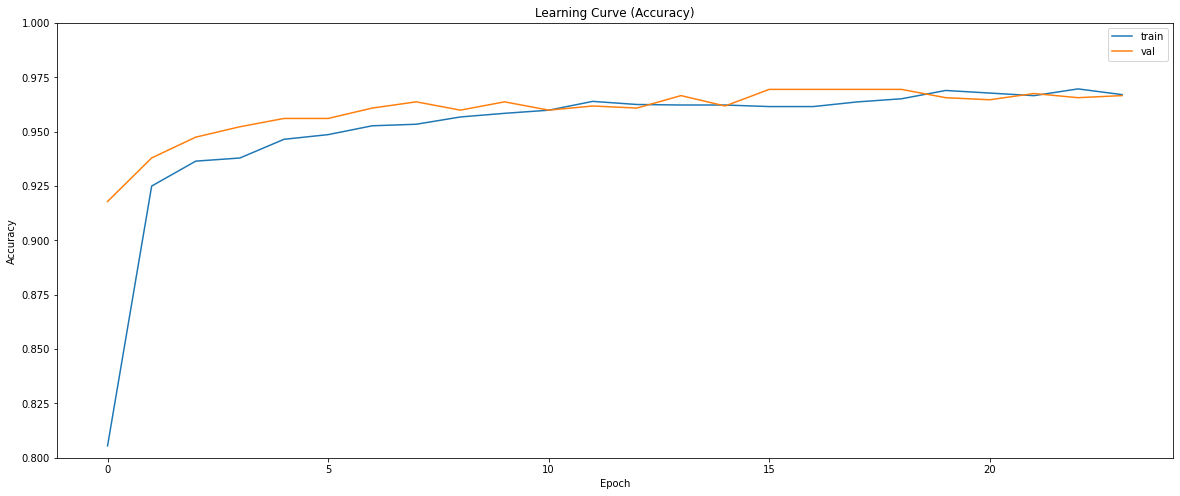

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['binary_accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_binary_accuracy'])
ax.set_title('Learning Curve (Accuracy)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim(0.80, 1.0)
ax.legend(['train', 'val'], loc='best')
plt.show()

In [ ]:
score = model_pretrained.evaluate(validation_generator, verbose = 0)
print('Val loss:', score[0])
print('Val accuracy:', score[1])

Val loss: 0.09604005515575409
Val accuracy: 0.9694364666938782


In [ ]:
score = model_pretrained.evaluate(test_datagen, verbose = 0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.28737810254096985
Test accuracy: 0.8814102411270142


# <a id="7">Fine Tuning</a>

Our last approach is called Fine Tuning. In the last section, all the layers from the pretrained model were ‘frozen’, preserving the weights calculated during its training on the ImageNet dataset. Now, we are going to unfreeze a few of its last layers and continue the training, tuning the weights from these layers according to our dataset.

In [ ]:
base_model.trainable = True

# Freeze all layers except for the
for layer in base_model.layers[:-13]:
    layer.trainable = False

In [ ]:
# Check which layers are tuneable (trainable)
for layer_number, layer in enumerate(base_model.layers):
    print(layer_number, layer.name, layer.trainable)

0 input_2 False
1 conv1_pad False
2 conv1_conv False
3 pool1_pad False
4 pool1_pool False
5 conv2_block1_preact_bn False
6 conv2_block1_preact_relu False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_pad False
11 conv2_block1_2_conv False
12 conv2_block1_2_bn False
13 conv2_block1_2_relu False
14 conv2_block1_0_conv False
15 conv2_block1_3_conv False
16 conv2_block1_out False
17 conv2_block2_preact_bn False
18 conv2_block2_preact_relu False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_pad False
23 conv2_block2_2_conv False
24 conv2_block2_2_bn False
25 conv2_block2_2_relu False
26 conv2_block2_3_conv False
27 conv2_block2_out False
28 conv2_block3_preact_bn False
29 conv2_block3_preact_relu False
30 conv2_block3_1_conv False
31 conv2_block3_1_bn False
32 conv2_block3_1_relu False
33 conv2_block3_2_pad False
34 conv2_block3_2_conv False
35 conv2_block3_2_bn False
36 conv2_bloc

In [ ]:
model_pretrained.compile(loss='binary_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=2e-6), metrics='binary_accuracy')

model_pretrained.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
resnet152v2 (Functional)     (None, 7, 7, 2048)        58331648  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               262272    
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 129       
Total params: 58,594,049
Trainable params: 4,731,137
Non-trainable params: 53,862,912
_________________________________________

In [ ]:
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=valid_generator,
    callbacks=[model_checkpoint_callback, early_stopping, reduce_lr])

Epoch 1/50
130/130 [==============================] - 104s 797ms/step - loss: 0.1608 - binary_accuracy: 0.9419 - val_loss: 0.1463 - val_binary_accuracy: 0.9570
Epoch 3/50
130/130 [==============================] - 103s 784ms/step - loss: 0.1316 - binary_accuracy: 0.9564 - val_loss: 0.1318 - val_binary_accuracy: 0.9608
Epoch 4/50
130/130 [==============================] - 103s 785ms/step - loss: 0.1370 - binary_accuracy: 0.9554 - val_loss: 0.1272 - val_binary_accuracy: 0.9608
Epoch 5/50
130/130 [==============================] - 103s 789ms/step - loss: 0.1315 - binary_accuracy: 0.9561 - val_loss: 0.1232 - val_binary_accuracy: 0.9628
Epoch 6/50
130/130 [==============================] - 103s 790ms/step - loss: 0.1176 - binary_accuracy: 0.9576 - val_loss: 0.1206 - val_binary_accuracy: 0.9618
Epoch 7/50
130/130 [==============================] - 103s 788ms/step - loss: 0.1156 - binary_accuracy: 0.9597 - val_loss: 0.1210 - val_binary_accuracy: 0.9589
Epoch 8/50
130/130 [====================

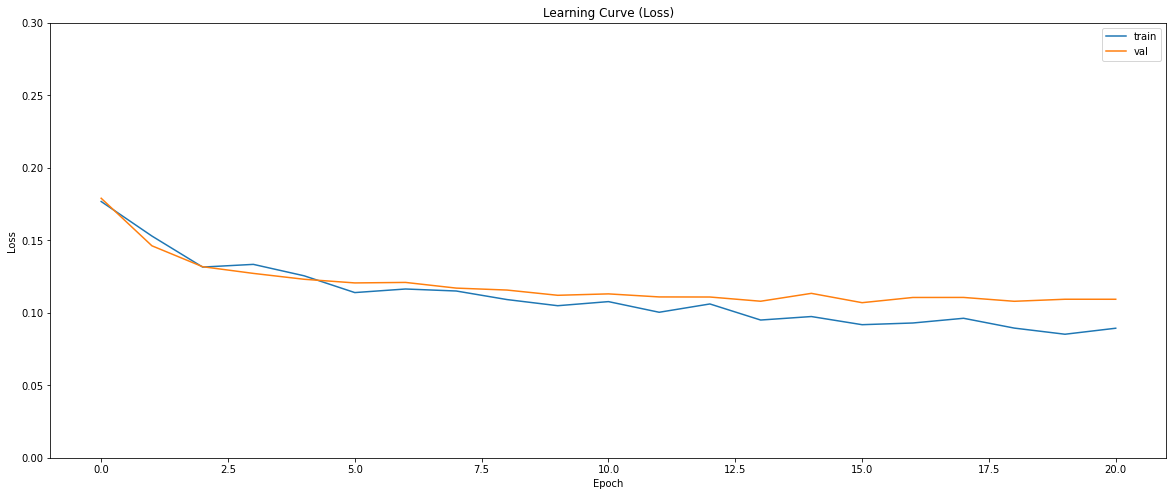

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 0.3)
ax.legend(['train', 'val'], loc='best')
plt.show()

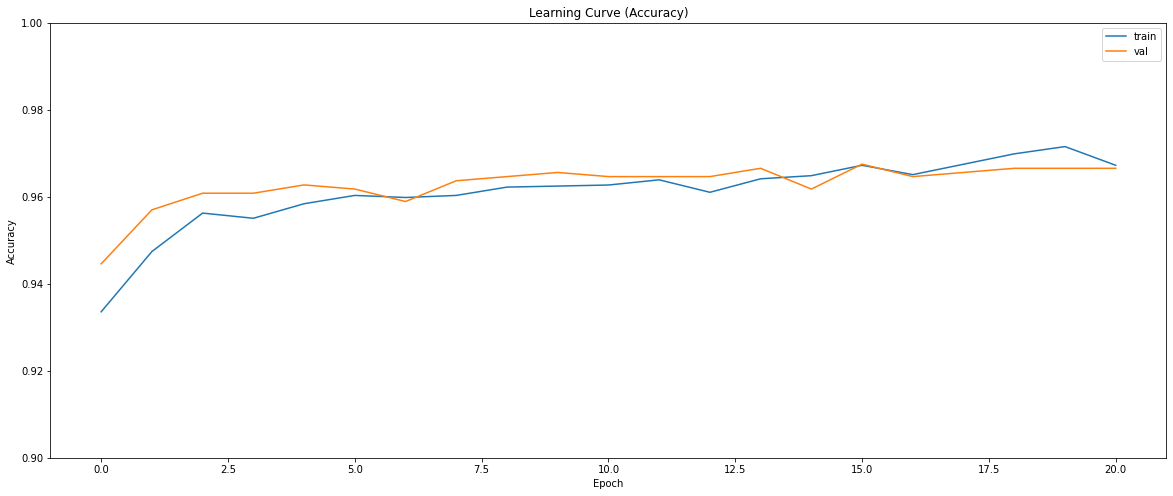

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['binary_accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_binary_accuracy'])
ax.set_title('Learning Curve (Accuracy)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim(0.90, 1.0)
ax.legend(['train', 'val'], loc='best')
plt.show()

In [ ]:
score = model_pretrained.evaluate(test_datagen, verbose = 0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.21019524335861206
Test accuracy: 0.9198718070983887
